# Sandbox Backend

Sandboxes allow your agent to execute arbitrary code, access files, and use the network without compromising the security of your host system. They are especially useful for things like

- coding agents
- data analysis agents

When configured with a sandbox your agent gets:
- All standard filesystem tools (**ls, read_file, write_file, edit_file, glob, grep**)
- The **execute** tool for running arbitrary shell commands in the sandbox
- A secure boundary that protects your host system

Supported sandbox backends include: **LangSmith, Daytona, E2B, Modal, Runloop, and Vercel**

In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
from dotenv import load_dotenv
load_dotenv(override=True)

import os, boto3
from util import pretty_print_with_code
from deepagents import create_deep_agent
from deepagents.backends import LangSmithSandbox
from langsmith.sandbox import (
    SandboxClient,
    aws_auth,
    mount_config,
    opaque_secret,
    s3_mount,
    workspace_secret,  # noqa: F401 -- shown as the production alternative below
)

model = "claude-haiku-4-5-20251001"

from langchain_openai import ChatOpenAI
import os

model = ChatOpenAI(
    openai_api_key=os.getenv("OPENAI_API_KEY"),
    openai_api_base=os.getenv("OPENAI_BASE_URL"),
    # model_name="gpt-5.5",
    model_name="gpt-5.6-luna",
    # Deep Agents uses function tools; reasoning + tools requires /v1/responses.
    use_responses_api=True,
    
)

# Building a Data Analysis Agent

Rather than asking an LLM to directly interpret a messy dataset, we can **safely generate and execute deterministic code** to do the analysis.

We will use a deliberately messy CSV file containing online orders for a fictional coffee roasting company. Like most real-world data, it's a little messy — inconsistent category casing, stray `$` signs in the revenue column, and a couple of missing values.

We will construct an agent to clean it, find the top products and the monthly revenue trend, and draw a chart — by **actually running code**.

In [4]:
messy_csv = """order_date,product,category,units,revenue
2026-01-03,Ethiopia Yirgacheffe,Single Origin,3,54.00
2026-01-06,House Blend,blend,2,$30.00
2026-01-11,Colombia Huila,single origin,2,34.00
2026-01-15,Espresso Roast,Espresso,4,64.00
2026-01-19,Breakfast Blend,Blend,1,14.00
2026-01-23,Decaf Espresso,decaf,2,32.00
2026-01-28,Ethiopia Yirgacheffe,SINGLE ORIGIN,2,36.00
2026-02-02,Colombia Huila,Single Origin,3,51.00
2026-02-05,House Blend,Blend,4,$60.00
2026-02-09,Sumatra Mandheling,single origin,3,57.00
2026-02-12,Espresso Roast,espresso,5,80.00
2026-02-14,Ethiopia Yirgacheffe,Single Origin,6,108.00
2026-02-18,Breakfast Blend,blend,3,42.00
2026-02-21,Decaf Espresso,Decaf,2,32.00
2026-02-25,Colombia Huila,Single Origin,4,68.00
2026-02-27,House Blend,Blend,3,45.00
2026-03-01,Ethiopia Yirgacheffe,Single Origin,8,144.00
2026-03-04,Sumatra Mandheling,SINGLE ORIGIN,5,95.00
2026-03-07,Espresso Roast,Espresso,6,$96.00
2026-03-10,House Blend,blend,5,75.00
2026-03-13,Colombia Huila,single origin,6,102.00
2026-03-16,Breakfast Blend,Blend,4,56.00
2026-03-19,Decaf Espresso,decaf,3,48.00
2026-03-22,Ethiopia Yirgacheffe,Single Origin,7,126.00
2026-03-25,Sumatra Mandheling,Single Origin,4,76.00
2026-03-28,Espresso Roast,espresso ,7,112.00
2026-03-30,House Blend,Blend,,45.00
2026-03-31,Colombia Huila,Single Origin,5,
"""

# Create the Sandbox

We'll give the agent a fresh Linux box built from the `python:3.12-slim` image. Inside it the agent can install packages and run whatever code it writes — none of which touches our host.

We seed the box with the customer's CSV at `/work/sales.csv`.

#### NOTE:
In this example we <code style="font-size:15px; color:#2b8a3e;">pip install</code> extra packages manually, however we could also have built a custom Docker image preloaded with the dependencies and tools.

In [5]:
SNAPSHOT_NAME = "data-analysis-sandbox"

client = SandboxClient()

# Reuse the snapshot across runs — create_snapshot returns 409 if the name already exists.
ready = [s for s in client.list_snapshots(name_contains=SNAPSHOT_NAME) if s.name == SNAPSHOT_NAME and s.status == "ready"]

snapshot = ready[0] if ready else client.create_snapshot(
    name=SNAPSHOT_NAME,
    docker_image="python:3.12-slim",
    fs_capacity_bytes=2 * 1024**3,  # 2 GiB — room for pip-installed pandas/matplotlib
)

sb = client.create_sandbox(snapshot_id=snapshot.id)
sandbox = LangSmithSandbox(sb)

sandbox.execute("mkdir -p /work")
sandbox.execute("pip install pandas matplotlib seaborn")
sandbox.upload_files([("/work/sales.csv", messy_csv.encode("utf-8"))])

print(sandbox.execute("head -n 5 /work/sales.csv").output)

order_date,product,category,units,revenue
2026-01-03,Ethiopia Yirgacheffe,Single Origin,3,54.00
2026-01-06,House Blend,blend,2,$30.00
2026-01-11,Colombia Huila,single origin,2,34.00
2026-01-15,Espresso Roast,Espresso,4,64.00



# Configure the Deep Agent to use the Sandbox

- Pass <code style="font-size:15px; color:#2b8a3e;">backend=sandbox</code>
- Our Deep agent gets the <code style="font-size:15px; color:#2b8a3e;">execute</code> tool

The agent will run all shell commands through the <code style="font-size:15px; color:#2b8a3e;">execute</code> tool.

In [6]:
analyst_prompt = """
You are a data analyst working inside a sandbox.
Your working directory is /work, and a CSV of online orders is at /work/sales.csv.
You can install packages and run code with the execute tool.

When analyzing data:
- Inspect and CLEAN the data first — watch for missing values, inconsistent
  category casing, and stray currency symbols like '$'.
- Write your analysis as a Python script and RUN it. Don't guess at numbers.
- Save any chart you produce to /work/chart.png.
"""

agent = create_deep_agent(
    model=model,
    backend=sandbox,
    system_prompt=analyst_prompt)

# Using the Sandbox

The Deep Agent automatically routes commands into the sandbox.

In [7]:
request = (
    "Here are my coffee roastery's online orders in /work/sales.csv — it's a bit messy. "
    "What are my top products by revenue, and what's the monthly revenue trend? "
    "Clean the data, compute the numbers, and save a chart to /work/chart.png."
)

result = agent.invoke({"messages": [{"role": "user", "content": request}]})
pretty_print_with_code(result)

### Human

Here are my coffee roastery's online orders in /work/sales.csv — it's a bit messy. What are my top products by revenue, and what's the monthly revenue trend? Clean the data, compute the numbers, and save a chart to /work/chart.png.

### Tool

['/work/sales.csv']

### Tool

 1  order_date,product,category,units,revenue
 2  2026-01-03,Ethiopia Yirgacheffe,Single Origin,3,54.00
 3  2026-01-06,House Blend,blend,2,$30.00
 4  2026-01-11,Colombia Huila,single origin,2,34.00
 5  2026-01-15,Espresso Roast,Espresso,4,64.00
 6  2026-01-19,Breakfast Blend,Blend,1,14.00
 7  2026-01-23,Decaf Espresso,decaf,2,32.00
 8  2026-01-28,Ethiopia Yirgacheffe,SINGLE ORIGIN,2,36.00
 9  2026-02-02,Colombia Huila,Single Origin,3,51.00
10  2026-02-05,House Blend,Blend,4,$60.00
11  2026-02-09,Sumatra Mandheling,single origin,3,57.00
12  2026-02-12,Espresso Roast,espresso,5,80.00
13  2026-02-14,Ethiopia Yirgacheffe,Single Origin,6,108.00
14  2026-02-18,Breakfast Blend,blend,3,42.00
15  2026-02-21,Decaf Espresso,Decaf,2,32.00
16  2026-02-25,Colombia Huila,Single Origin,4,68.00
17  2026-02-27,House Blend,Blend,3,45.00
18  2026-03-01,Ethiopia Yirgacheffe,Single Origin,8,144.00
19  2026-03-04,Sumatra Mandheling,SINGLE ORIGIN,5,95.00
20  2026-03-07,Espresso Roast,Espresso,6,$96.00

[Read 20 lines (lines 1-20 of 29 total). 9 lines remaining from offset 20.]

### Tool

21  2026-03-10,House Blend,blend,5,75.00
22  2026-03-13,Colombia Huila,single origin,6,102.00
23  2026-03-16,Breakfast Blend,Blend,4,56.00
24  2026-03-19,Decaf Espresso,decaf,3,48.00
25  2026-03-22,Ethiopia Yirgacheffe,Single Origin,7,126.00
26  2026-03-25,Sumatra Mandheling,Single Origin,4,76.00
27  2026-03-28,Espresso Roast,espresso ,7,112.00
28  2026-03-30,House Blend,Blend,,45.00
29  2026-03-31,Colombia Huila,Single Origin,5,

### Tool

Updated file /work/analyze_sales.py

### Tool

Rows analyzed: 28
Missing units imputed: 1
Missing revenue imputed: 1

Top products by revenue:
Ethiopia Yirgacheffe: $468.00
Espresso Roast: $352.00
Colombia Huila: $340.00
House Blend: $255.00
Sumatra Mandheling: $228.00
Decaf Espresso: $112.00
Breakfast Blend: $112.00

Monthly revenue:
2026-01: $264.00
2026-02: $543.00
2026-03: $1,060.00

Chart saved to /work/chart.png

[Command succeeded with exit code 0]

### Tool

['/work/analyze_sales.py', '/work/chart.png', '/work/sales.csv']

### Ai

Cleaned the 28 orders by:

- Removing `$` symbols and parsing numeric fields
- Standardizing category casing and whitespace
- Imputing 1 missing units value from the row’s revenue and product unit price
- Imputing 1 missing revenue value using the product’s observed unit price

## Top products by revenue

| Rank | Product | Revenue |
|---:|---|---:|
| 1 | Ethiopia Yirgacheffe | $468.00 |
| 2 | Espresso Roast | $352.00 |
| 3 | Colombia Huila | $340.00 |
| 4 | House Blend | $255.00 |
| 5 | Sumatra Mandheling | $228.00 |
| 6 | Decaf Espresso | $112.00 |
| 7 | Breakfast Blend | $112.00 |

## Monthly revenue trend

| Month | Revenue |
|---|---:|
| January 2026 | $264.00 |
| February 2026 | $543.00 |
| March 2026 | $1,060.00 |

Revenue increased each month: approximately **106% from January to February** and **95% from February to March**. Total revenue was **$1,867.00**.

The combined product-revenue and monthly-trend chart is saved at:

`/work/chart.png`

The reproducible analysis script is at:

`/work/analyze_sales.py`

# Working with Files

All Sandbox implementations support bulk file operations:
- download_files
- upload_files

This is in addition to the standard filesystem tools we have previously seen.

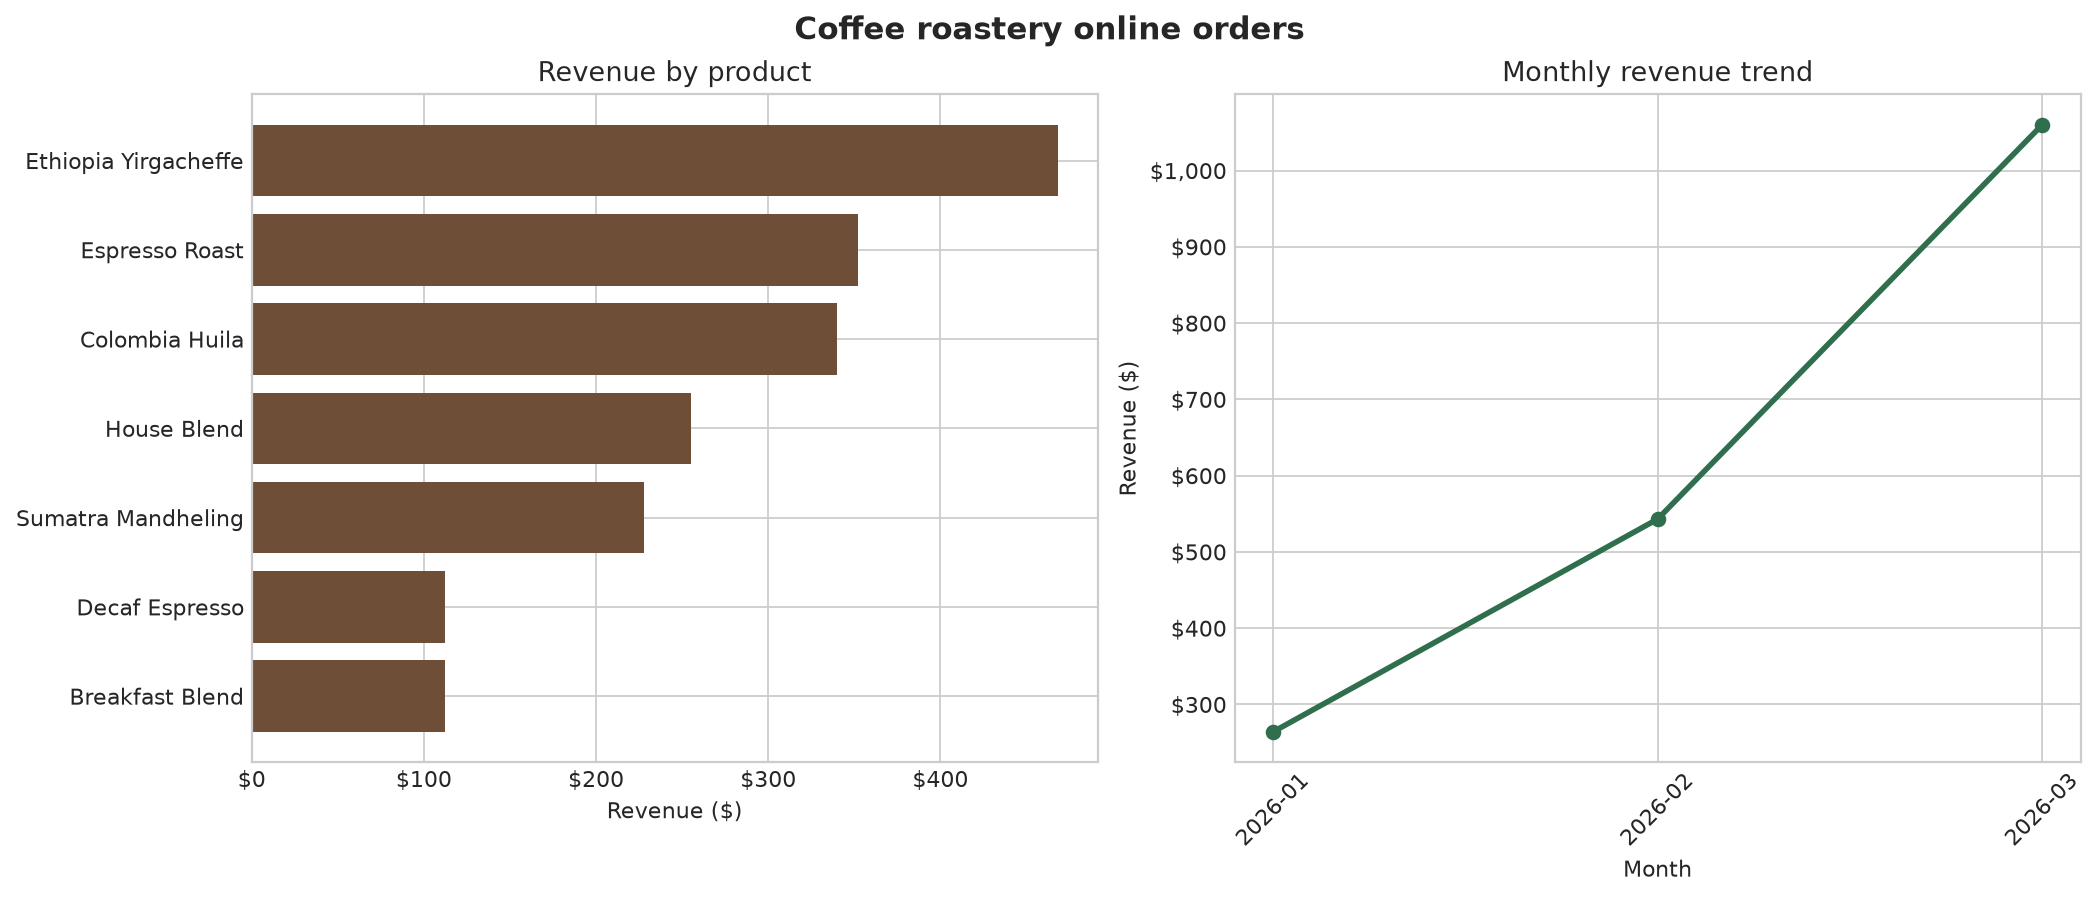

In [8]:
from IPython.display import Image

download = sandbox.download_files(["/work/chart.png"])[0]
assert download.content, f"download failed: {download.error}"

with open("images/coffee-chart.png", "wb") as f:
    f.write(download.content)

Image(data=download.content)

# Peek inside the sandbox

Everything the agent created is still in `/work`: the analysis script it wrote and the chart it rendered.

In [9]:
print(sandbox.execute("ls -la /work").output)

total 124
drwxr-xr-x  2 root root   4096 Sep  6 22:34 .
drwxr-xr-x 20 root root   4096 Sep  6 22:34 ..
-rw-r--r--  1 root root   3541 Sep  6 22:34 analyze_sales.py
-rw-r--r--  1 root root 107333 Sep  6 22:34 chart.png
-rw-r--r--  1 root root   1311 Sep  6 22:33 sales.csv



# Clean up

Delete the sandbox when we're done. (LangSmith sandboxes also auto-stop after an idle timeout.)

In [10]:
sb.delete()
print("sandbox deleted")

sandbox deleted


# Recap

- A **sandbox backend** gives the agent a real filesystem, a shell, and package installs — behind a security boundary that protects the host.
- Configuring `backend=sandbox` adds the **execute** tool automatically, on top of the usual `ls / read_file / write_file / edit_file / glob / grep`.
- The agent *ran actual code* to answer the question — cleaning the data, computing the numbers, and rendering a chart. The downloaded `chart.png` is the proof.
- Seed inputs into the box with `upload_files`, collect outputs with `download_files`.

# Sandbox Mounts

Cloud object stores and GitHub repositories can be **mounted** into a sandbox as regular filesystems.

Use mounts when sandbox code needs direct file access to object storage buckets or public Git repositories without copying the data into the sandbox image.

Mounts are configured through the <code style="font-size:15px; color:#2b8a3e;">mount_config</code> option and are fixed at creation — to change them you create a new sandbox.


In [10]:
S3_BUCKET       = os.environ["S3_BUCKET"]
S3_REGION       = os.environ["S3_REGION"]
S3_ENDPOINT     = f"https://s3.{S3_REGION}.amazonaws.com"
DEMO_PREFIX     = "deepagents-demo"
INPUT_PREFIX    = f"{DEMO_PREFIX}/input"
OUTPUT_PREFIX   = f"{DEMO_PREFIX}/output"

s3 = boto3.client(
    "s3",
    region_name=S3_REGION,
    aws_access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
    aws_secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"],
)

s3.put_object(
    Bucket=S3_BUCKET,
    Key=f"{INPUT_PREFIX}/sales.csv",
    Body=messy_csv.encode("utf-8"),
)

print(f"staged s3://{S3_BUCKET}/{INPUT_PREFIX}/sales.csv")

staged s3://andrew-us-west-1-test-bucket/deepagents-demo/input/sales.csv


# Configure S3 Mount

A <code style="font-size:15px; color:#2b8a3e;">mount_config</code> consists of:
- <code style="font-size:15px; color:#2b8a3e;">auth</code> - Provider credentials the sandbox proxy uses to sign requests
- <code style="font-size:15px; color:#2b8a3e;">mounts</code> One `s3_mount` per bucket location.

Mount paths must live under `/mnt/mounts`. We mount the input prefix **read-only** and the output prefix **writable** (`read_only=False`), so anything the agent saves to the output mount is flushed back to the bucket.

#### Two ways to supply credentials

- <code style="font-size:15px; color:#2b8a3e;">opaque_secret(value)</code> — hands the proxy the literal value. Convenient in a notebook, but the credential is in your process.
- <code style="font-size:15px; color:#2b8a3e;">workspace_secret(name)</code> — hands it the *name* of a secret stored in your LangSmith workspace. **This is the production form**: the value never reaches your code, your notebook, or your source control.

In [11]:
INPUT_MOUNT = "/mnt/mounts/data/input"
OUTPUT_MOUNT = "/mnt/mounts/data/output"

mount_cfg = mount_config(
    auth=[
        aws_auth(
            # In production, reference secrets stored in your LangSmith workspace
            # so the values never appear in your code:
            #     access_key_id=workspace_secret("AWS_ACCESS_KEY_ID"),
            #     secret_access_key=workspace_secret("AWS_SECRET_ACCESS_KEY"),
            access_key_id=opaque_secret(os.environ["AWS_ACCESS_KEY_ID"]),
            secret_access_key=opaque_secret(os.environ["AWS_SECRET_ACCESS_KEY"]),
        )
    ],
    mounts=[
        s3_mount(
            id="data_input",
            mount_path=INPUT_MOUNT,
            bucket=S3_BUCKET,
            region=S3_REGION,
            endpoint_url=S3_ENDPOINT,
            prefix=INPUT_PREFIX,
            read_only=True,
        ),
        s3_mount(
            id="data_output",
            mount_path=OUTPUT_MOUNT,
            bucket=S3_BUCKET,
            region=S3_REGION,
            endpoint_url=S3_ENDPOINT,
            prefix=OUTPUT_PREFIX,
            read_only=False,
        ),
    ],
)

# Mount S3 Bucket into the Sandbox

We boot from the same <code style="font-size:15px; color:#2b8a3e;">python:3.12-slim</code> snapshot, but now pass <code style="font-size:15px; color:#2b8a3e;">mount_config=mount_cfg</code> to <code style="font-size:15px; color:#2b8a3e;">create_sandbox</code>.

Notice there's **no `upload_files`**: the CSV is already visible inside the box the moment it
comes up, straight from S3.

In [12]:
client = SandboxClient()

# Reuse the snapshot across runs -- create_snapshot returns 409 if the name already exists.
ready = [s for s in client.list_snapshots(name_contains=SNAPSHOT_NAME)
         if s.name == SNAPSHOT_NAME and s.status == "ready"]

snapshot = ready[0] if ready else client.create_snapshot(
    name=SNAPSHOT_NAME,
    docker_image="python:3.12-slim",
    fs_capacity_bytes=2 * 1024**3,  # 2 GiB -- room for pip-installed pandas/matplotlib
)

sb = client.create_sandbox(snapshot_id=snapshot.id, mount_config=mount_cfg)
sandbox = LangSmithSandbox(sb)

print("sandbox:", sandbox.id)
print(sandbox.execute(f"ls -la {INPUT_MOUNT}").output)
print(sandbox.execute(f"head -n 5 {INPUT_MOUNT}/sales.csv").output)

sandbox: sandbox-agp25f7ndvz5fndr5w2h5jaodi
total 6
drwxr-xr-x 1 root root    0 Jul 29 15:57 .
drwxr-xr-x 4 root root 4096 Jul 29 15:57 ..
-rw-r--r-- 1 root root 1311 Jul 29 15:57 sales.csv

order_date,product,category,units,revenue
2026-01-03,Ethiopia Yirgacheffe,Single Origin,3,54.00
2026-01-06,House Blend,blend,2,$30.00
2026-01-11,Colombia Huila,single origin,2,34.00
2026-01-15,Espresso Roast,Espresso,4,64.00



# Write back through the mount

The output mount was configured with <code style="font-size:15px; color:#2b8a3e;">read_only=False</code>, so it works in both directions. Anything written under <code style="font-size:15px; color:#2b8a3e;">/mnt/mounts/data/output</code> is flushed straight back to the bucket.

Note what is **absent**: the sandbox never calls <code style="font-size:15px; color:#2b8a3e;">put_object</code>, and we never call <code style="font-size:15px; color:#2b8a3e;">download_files</code> / <code style="font-size:15px; color:#2b8a3e;">upload_files</code>. To the code inside the box it is an ordinary file write.

In [13]:
# An ordinary shell redirect inside the sandbox - reads the read-only mount,
# writes the writable one.
sandbox.execute(f"wc -l < {INPUT_MOUNT}/sales.csv > {OUTPUT_MOUNT}/row_count.txt")
print(sandbox.execute(f"ls -la {OUTPUT_MOUNT}").output)

# Now read it straight out of S3. Nothing in this notebook uploaded that object.
for obj in s3.list_objects_v2(Bucket=S3_BUCKET, Prefix=OUTPUT_PREFIX).get("Contents", []):
    body = s3.get_object(Bucket=S3_BUCKET, Key=obj["Key"])["Body"].read().decode()
    print(f"s3://{S3_BUCKET}/{obj['Key']} -> {body.strip()}")

total 5
drwxr-xr-x 1 root root    0 Jul 29 15:57 .
drwxr-xr-x 4 root root 4096 Jul 29 15:57 ..
-rw-r--r-- 1 root root    3 Jul 29 15:57 row_count.txt

s3://andrew-us-west-1-test-bucket/deepagents-demo/output/row_count.txt -> 29


In [14]:
sb.delete()
print("sandbox deleted")

objs = s3.list_objects_v2(Bucket=S3_BUCKET, Prefix=f"{DEMO_PREFIX}/").get("Contents", [])
if objs:
    s3.delete_objects(Bucket=S3_BUCKET, Delete={"Objects": [{"Key": o["Key"]} for o in objs]})
    print(f"removed {len(objs)} demo object(s) from s3://{S3_BUCKET}/{DEMO_PREFIX}/")

sandbox deleted
removed 2 demo object(s) from s3://andrew-us-west-1-test-bucket/deepagents-demo/


# Summary

- **A sandbox backend is a real Linux box** — filesystem, shell, and package installs — behind a boundary that protects the host. Supported: **LangSmith, Daytona, E2B, Modal, Runloop, Vercel**.
- **`backend=sandbox` adds the `execute` tool** on top of the usual `ls / read_file / write_file / edit_file / glob / grep`. Nothing else about the agent definition changes.
- **The agent wrote and ran code rather than eyeballing the CSV.** It cleaned the inconsistent category casing, the stray `$` signs and the missing values, computed top products and the monthly trend, and rendered `/work/chart.png` — deterministic numbers instead of a model's guess. `ls -la /work` afterwards shows both the script it wrote and the chart.
- **Snapshots are the reusable unit.** `create_snapshot(docker_image=..., fs_capacity_bytes=...)` once, then `create_sandbox(snapshot_id=...)` per run. We `pip install`ed pandas/matplotlib/seaborn at boot; baking them into a custom image avoids paying that cost every run.

Two ways to get data in and out:

<table style="font-size:18px; border-collapse:collapse; width:100%;">
<thead>
<tr>
<th style="border:1px solid #999; padding:12px; text-align:left;">Approach</th>
<th style="border:1px solid #999; padding:12px; text-align:left;">Reach for it when</th>
</tr>
</thead>
<tbody>
<tr>
<td style="border:1px solid #999; padding:12px; text-align:left; vertical-align:top;">Transfer<br><code style="font-size:15px; color:#2b8a3e;">sandbox.upload_files([...])</code><br><code style="font-size:15px; color:#2b8a3e;">sandbox.download_files([...])</code></td>
<td style="border:1px solid #999; padding:12px; text-align:left; vertical-align:top;">One-off inputs and artifacts. We seeded <code style="font-size:15px; color:#2b8a3e;">/work/sales.csv</code> into the box and pulled <code style="font-size:15px; color:#2b8a3e;">chart.png</code> back out.</td>
</tr>
<tr>
<td style="border:1px solid #999; padding:12px; text-align:left; vertical-align:top;">Mount<br><code style="font-size:15px; color:#2b8a3e;">create_sandbox(snapshot_id=..., mount_config=mount_config(auth=[aws_auth(...)], mounts=[s3_mount(...)]))</code></td>
<td style="border:1px solid #999; padding:12px; text-align:left; vertical-align:top;">The data already lives in an object store or a public Git repo and you don't want a copy inside the image. Mounts are fixed at creation and must live under <code style="font-size:15px; color:#2b8a3e;">/mnt/mounts</code> — to change them, create a new sandbox.</td>
</tr>
</tbody>
</table>

- **Direction is per-mount:** `read_only=True` on the input prefix, `read_only=False` on the output prefix so that anything written there is flushed back to the bucket. With the bucket mounted there is **no `upload_files` step** — the CSV is visible the moment the box boots.
- **Secrets:** `opaque_secret(value)` passes the value straight through, which is fine for a demo; `workspace_secret(name)` is the production alternative, keeping the credential in the LangSmith workspace rather than the notebook.
- **Clean up:** `sb.delete()` when finished (LangSmith sandboxes also auto-stop after an idle timeout), plus any demo objects staged in the bucket.